# Imports

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from category_encoders.cat_boost import CatBoostEncoder
from scipy.stats import ks_2samp
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from skopt import BayesSearchCV
from skopt.space import Integer, Real
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, make_scorer, roc_curve

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

# Reading Bases

In [3]:
df_train = pd.read_csv('C:/Users/joaov/OneDrive/Área de Trabalho/Python/cloudwalk-challenge/data/processed/train_processed.csv')
df_test = pd.read_csv('C:/Users/joaov/OneDrive/Área de Trabalho/Python/cloudwalk-challenge/data/processed/test_processed.csv')

# Preprocessing

## Selecting data

In [5]:
df_train.columns

Index(['transaction_id', 'merchant_id', 'user_id', 'card_number',
       'transaction_date', 'transaction_amount', 'device_id', 'has_cbk',
       'transaction_hour', 'transaction_day', 'transaction_period',
       'mean_amount_day', 'median_amount_day', 'diff_from_mean_day',
       'ratio_to_mean_day', 'mean_amount_period', 'diff_from_mean_period',
       'ratio_to_mean_period', 'mean_amount_user', 'median_amount_user',
       'diff_from_user_mean', 'ratio_to_user_mean'],
      dtype='object')

In [7]:
df_train[['transaction_id', 'merchant_id', 'user_id', 'device_id']] = df_train[['transaction_id', 'merchant_id', 'user_id', 'device_id']].astype('category')

In [8]:
drop_cols = ['transaction_id', 'card_number']

In [ ]:
train_data_categ = df_train.select_dtypes(include=['object', 'category']).drop(drop_cols, axis=1)
train_data_num = df_train.select_dtypes(exclude=['object', 'category']).drop('has_cbk', axis=1)

## Processing Pipeline

In [26]:
num_transf = Pipeline(steps=[('imputer', SimpleImputer(strategy='mean')),
                             ('scaler', MinMaxScaler())])
cat_transf = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                             ('encoder', CatBoostEncoder()),
                             ('scaler', MinMaxScaler())])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transf, train_data_num.columns),
        ('cat', cat_transf, train_data_categ.columns)
    ], remainder='drop'
)

prep_pipe = Pipeline(steps=[('preprocessor', preprocessor)])

In [27]:
x_train, y_train = df_train.drop(['has_cbk'] + drop_cols, axis=1), df_train['has_cbk'].astype(int)

x_prep = prep_pipe.fit_transform(x_train, y_train)

# Hyperparameter Tuning

In [48]:
# Função para calcular KS Statistic
def ks_statistic(estimator, X, y):
    """
    Calcula a estatística KS (Kolmogorov-Smirnov) - compatível com make_scorer
    """
    # Obter probabilidades do modelo
    if hasattr(estimator, 'predict_proba'):
        y_prob = estimator.predict_proba(X)[:, 1]
    elif hasattr(estimator, 'decision_function'):
        y_prob = estimator.decision_function(X)
    else:
        # Fallback para modelos que só têm predict
        y_prob = estimator.predict(X)
    
    # Separar as probabilidades por classe
    pos_scores = y_prob[y == 1]
    neg_scores = y_prob[y == 0]
    
    # Calcular KS statistic
    ks_stat, p_value = ks_2samp(pos_scores, neg_scores)
    return ks_stat

# Modelos atualizados (adicionando Isolation Forest)
models = {
    'xgb': XGBClassifier(eval_metric='auc', random_state=42),
    'rf': RandomForestClassifier(random_state=42),
    'isolation': IsolationForest(contamination='auto', random_state=42)  # Novo modelo
}

# Hyperparameter Tuning (adicionando parâmetros do Isolation Forest)
params = {
    'xgb': {
        'n_estimators': Integer(100, 500),
        'max_depth': Integer(3, 20),
        'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
        'subsample': Real(0.5, 1.0)
    },
    'rf': {
        'n_estimators': Integer(100, 500),
        'max_depth': Integer(3, 20),
        'min_samples_split': Integer(2, 10),
        'min_samples_leaf': Integer(1, 10)
    },
    'isolation': {  # Novos parâmetros
        'n_estimators': Integer(50, 300),
        'max_samples': Real(0.1, 1.0),
        'contamination': Real(0.01, 0.5),
        'max_features': Real(0.1, 1.0)
    }
}

cv = KFold(n_splits=3, shuffle=True, random_state=42)

grids = {}

# Scoring atualizado (removendo KS temporariamente do scoring automático)
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='binary'),
    'recall': make_scorer(recall_score, average='binary'),
    'f1_score': make_scorer(f1_score, average='binary'),
    'auc': make_scorer(roc_auc_score)
    # KS será calculado manualmente após o treinamento
}

# Treinar modelos com tratamento especial para Isolation Forest
for model_name, model in models.items():
    
    if model_name == 'isolation':
        # Para Isolation Forest, vamos usar uma abordagem mais simples
        # Sem cross-validation para evitar problemas com scoring
        
        print(f"\n{'='*50}")
        print(f"TREINANDO {model_name.upper()} (Grid Search Manual)")
        print(f"{'='*50}")
        
        best_score = 0
        best_params = None
        best_model = None
        
        # Grid search manual para Isolation Forest
        contamination_values = [0.01, 0.05, 0.1, 0.2, 0.3]
        n_estimators_values = [50, 100, 200]
        max_samples_values = [0.5, 0.8, 1.0]
        
        for cont in contamination_values:
            for n_est in n_estimators_values:
                for max_samp in max_samples_values:
                    iso_model = IsolationForest(
                        contamination=cont,
                        n_estimators=n_est,
                        max_samples=max_samp,
                        random_state=42
                    )
                    
                    iso_model.fit(x_prep)
                    predictions = iso_model.predict(x_prep)
                    predictions_binary = np.where(predictions == -1, 1, 0)
                    
                    score = f1_score(y_train, predictions_binary)
                    
                    if score > best_score:
                        best_score = score
                        best_params = {
                            'contamination': cont,
                            'n_estimators': n_est,
                            'max_samples': max_samp
                        }
                        best_model = iso_model
        
        # Criar um objeto "grid" fake para compatibilidade
        class FakeGrid:
            def __init__(self, model, params):
                self.best_estimator_ = model
                self.best_params_ = params
                self.best_score_ = best_score
        
        grids[model_name] = FakeGrid(best_model, best_params)
        
        print(f"Melhor combinação de parâmetros: {best_params}")
        print(f"Melhor F1-Score: {best_score:.4f}")
        
    else:
        # Modelos supervisionados tradicionais
        grids[model_name] = BayesSearchCV(
            estimator=model, 
            search_spaces=params[model_name], 
            cv=cv, 
            scoring=scoring, 
            refit='precision', 
            n_jobs=-1, 
            verbose=2
        )
    
    if model_name != 'isolation':  # Só fazer fit para modelos supervisionados
        grids[model_name].fit(x_prep, y_train)
    
    print(f"\n{'='*50}")
    print(f"RESULTADOS PARA {model_name.upper()}")
    print(f"{'='*50}")
    
    if model_name == 'isolation':
        # Resultados já calculados no grid search manual
        best_model = grids[model_name].best_estimator_
        best_params = grids[model_name].best_params_
        
        print(f"Melhor combinação de parâmetros: {best_params}")
        
        # Fazer predições no conjunto de treino para avaliar todas as métricas
        train_pred = best_model.predict(x_prep)
        train_pred_binary = np.where(train_pred == -1, 1, 0)
        
        print(f"  Accuracy: {accuracy_score(y_train, train_pred_binary):.4f}")
        print(f"  Precision: {precision_score(y_train, train_pred_binary):.4f}")
        print(f"  Recall: {recall_score(y_train, train_pred_binary):.4f}")
        print(f"  F1-Score: {f1_score(y_train, train_pred_binary):.4f}")
        
        # Calcular KS manualmente
        try:
            ks_score = ks_statistic(best_model, x_prep, y_train)
            print(f"  KS Statistic: {ks_score:.4f}")
        except Exception as e:
            print(f"  KS Statistic: Erro - {str(e)}")
            
    else:
        # Modelos supervisionados tradicionais
        best_model = grids[model_name].best_estimator_
        best_index = grids[model_name].best_index_
        results = grids[model_name].cv_results_
        
        print(f"Melhor combinação de parâmetros: {results['params'][best_index]}")
        
        for score in scoring:
            mean_score = results[f'mean_test_{score}'][best_index]
            std_score = results[f'std_test_{score}'][best_index]
            print(f"  {score.capitalize()}: Média = {mean_score:.4f}, Desvio Padrão = {std_score:.4f}")
        
        # Calcular KS manualmente para modelos supervisionados
        try:
            ks_score = ks_statistic(best_model, x_prep, y_train)
            print(f"  KS Statistic: {ks_score:.4f}")
        except Exception as e:
            print(f"  KS Statistic: Erro - {str(e)}")

# Função adicional para comparar todos os modelos
def compare_models_with_ks(grids, X_test, y_test):
    """
    Compara todos os modelos incluindo KS statistic
    """
    print(f"\n{'='*60}")
    print("COMPARAÇÃO FINAL DOS MODELOS (Conjunto de Teste)")
    print(f"{'='*60}")
    
    results_comparison = {}
    
    for model_name, grid in grids.items():
        best_model = grid.best_estimator_
        
        if model_name == 'isolation':
            # Isolation Forest
            test_pred = best_model.predict(X_test)
            test_pred_binary = np.where(test_pred == -1, 1, 0)
            
            # Métricas básicas
            acc = accuracy_score(y_test, test_pred_binary)
            prec = precision_score(y_test, test_pred_binary)
            rec = recall_score(y_test, test_pred_binary)
            f1 = f1_score(y_test, test_pred_binary)
            
            # KS usando decision_function
            try:
                ks_score = ks_statistic(best_model, X_test, y_test)
                test_scores = best_model.decision_function(X_test)
                auc_score = roc_auc_score(y_test, test_scores)
            except:
                ks_score = None
                auc_score = None
            
        else:
            # Modelos supervisionados
            test_pred = best_model.predict(X_test)
            test_pred_proba = best_model.predict_proba(X_test)[:, 1]
            
            acc = accuracy_score(y_test, test_pred)
            prec = precision_score(y_test, test_pred)
            rec = recall_score(y_test, test_pred)
            f1 = f1_score(y_test, test_pred)
            auc_score = roc_auc_score(y_test, test_pred_proba)
            ks_score = ks_statistic(best_model, X_test, y_test)
        
        results_comparison[model_name] = {
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1-Score': f1,
            'AUC': auc_score,
            'KS': ks_score
        }
        
        print(f"\n🤖 {model_name.upper()}:")
        print(f"   Accuracy:  {acc:.4f}")
        print(f"   Precision: {prec:.4f}")
        print(f"   Recall:    {rec:.4f}")
        print(f"   F1-Score:  {f1:.4f}")
        if auc_score is not None:
            print(f"   AUC:       {auc_score:.4f}")
        if ks_score is not None:
            print(f"   KS:        {ks_score:.4f}")
    
    return results_comparison

# Uso da função de comparação:
# results_comparison = compare_models_with_ks(grids, X_test, y_test)

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fi

# Test Dataset

In [51]:
x_test, y_test = df_test.drop(['has_cbk'] + drop_cols, axis=1), df_test['has_cbk'].astype(int)
x_test_prep = prep_pipe.transform(x_test)

In [52]:
compare_models_with_ks(grids, x_test_prep, y_test)


COMPARAÇÃO FINAL DOS MODELOS (Conjunto de Teste)

🤖 XGB:
   Accuracy:  0.9313
   Precision: 0.9048
   Recall:    0.4872
   F1-Score:  0.6333
   AUC:       0.9121
   KS:        0.7098

🤖 RF:
   Accuracy:  0.9406
   Precision: 0.8704
   Recall:    0.6026
   F1-Score:  0.7121
   AUC:       0.9215
   KS:        0.7027

🤖 ISOLATION:
   Accuracy:  0.8484
   Precision: 0.4286
   Recall:    0.7308
   F1-Score:  0.5403
   AUC:       0.1303
   KS:        0.6490


{'xgb': {'Accuracy': 0.93125,
  'Precision': 0.9047619047619048,
  'Recall': 0.48717948717948717,
  'F1-Score': 0.6333333333333333,
  'AUC': 0.9121156127383886,
  'KS': np.float64(0.7098275390090337)},
 'rf': {'Accuracy': 0.940625,
  'Precision': 0.8703703703703703,
  'Recall': 0.6025641025641025,
  'F1-Score': 0.7121212121212122,
  'AUC': 0.9214800620494571,
  'KS': np.float64(0.7027101012866137)},
 'isolation': {'Accuracy': 0.8484375,
  'Precision': 0.42857142857142855,
  'Recall': 0.7307692307692307,
  'F1-Score': 0.5402843601895735,
  'AUC': 0.13028104754083403,
  'KS': np.float64(0.6489643215621863)}}

# Avaliation

In [54]:
model = grids['xgb'].best_estimator_
model.fit(x_prep, y_train)
y_pred_train = model.predict(x_prep)
y_pred_test = model.predict(x_test_prep)

In [ ]:
y_score_train = model.predict_proba(x_prep)[:, 1]
y_score_test = model.predict_proba(x_test_prep)[:, 1]

## Precision

In [55]:
acc_train = precision_score(y_train, y_pred_train)
acc_valid = precision_score(y_test, y_pred_test)
print(f"Precisão treino: {acc_train:.4f}")
print(f"Precisão validação: {acc_valid:.4f}")

Precisão treino: 0.9299
Precisão validação: 0.9048


## KS

In [69]:
ks_treino = ks_2samp(y_train, y_score_train)
ks_test = ks_2samp(y_test, y_score_test)
print(f"KS treino: {ks_treino.statistic:.2%}")  
print(f"KS teste: {ks_test.statistic:.2%}")

KS treino: 87.77%
KS teste: 87.81%


## Confusion Matrix

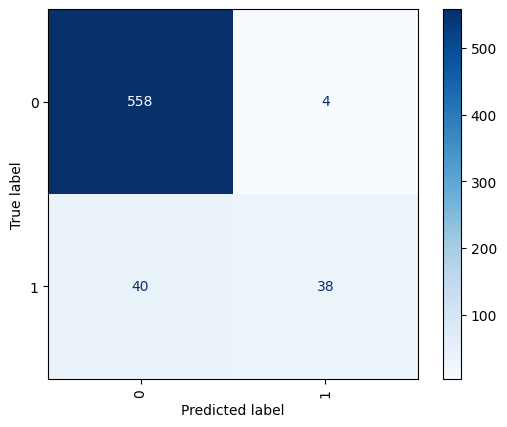

In [56]:
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred_test, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(xticks_rotation='vertical', cmap='Blues')

## Roc Curve

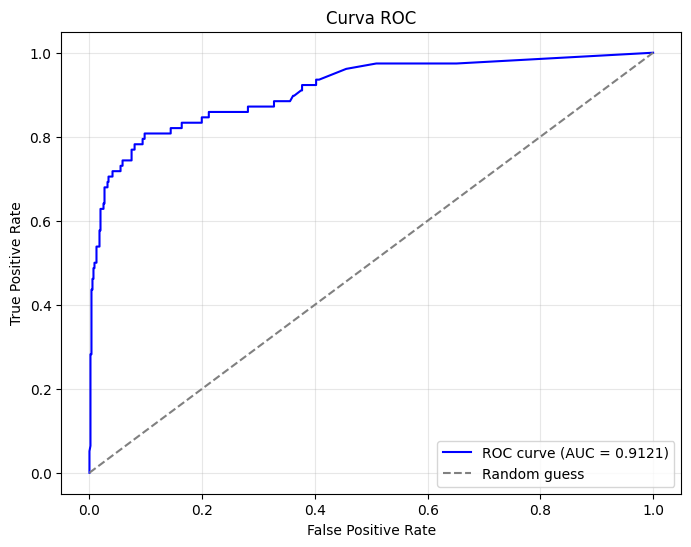

In [59]:
y_pred_proba = model.predict_proba(x_test_prep)[:, 1]

# Calcular pontos da curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Plotar curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="blue", label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## Quantil Analysis

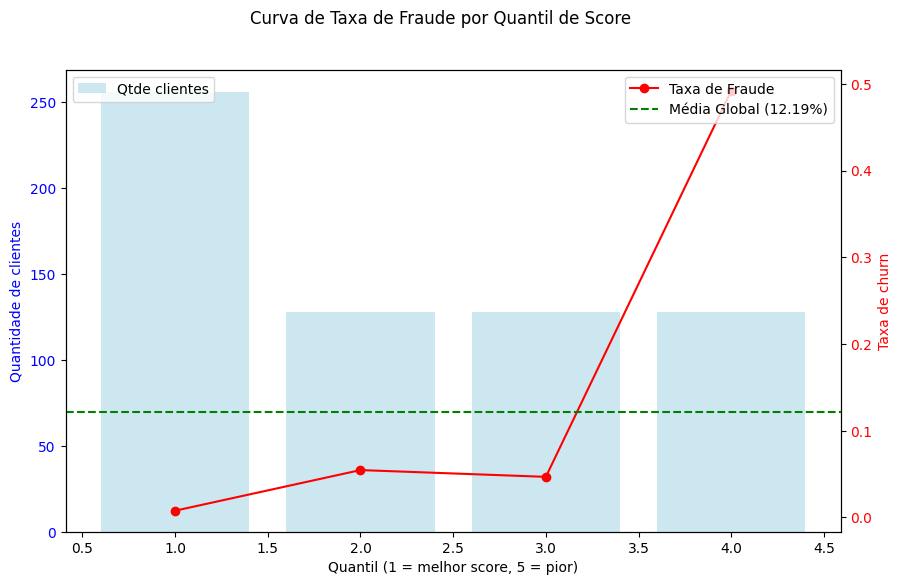

Tabela por quantil:
   quantil  total  fraudes      rate      lift
0        1    256        2  0.007812  0.064103
1        2    128        7  0.054688  0.448718
2        3    128        6  0.046875  0.384615
3        4    128       63  0.492188  4.038462

KS Statistic: 0.7098


In [76]:
df_test['SCORE_CHURN'] = y_pred_proba
# Garantir que SCORE_CHURN está no df_test
df_test = df_test.copy()
df_test['quantil'] = pd.qcut(df_test['SCORE_CHURN'], 5, labels=False, duplicates="drop") + 1  # 1 = pior, 10 = melhor score

# Agrupar por quantil
grouped = df_test.groupby('quantil').agg(
    total=('has_cbk', 'count'),
    fraudes=('has_cbk', 'sum')
).reset_index()

grouped['rate'] = grouped['fraudes'] / grouped['total']
global_mean = df_test['has_cbk'].mean()

# Lift = taxa do grupo / taxa global
grouped['lift'] = grouped['rate'] / global_mean

# --- KS ---
fpr, tpr, thresholds = roc_curve(df_test['has_cbk'], df_test['SCORE_CHURN'])
ks = max(tpr - fpr)

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barras (quantidade de clientes)
ax1.bar(grouped['quantil'], grouped['total'], color='lightblue', alpha=0.6, label='Qtde clientes')
ax1.set_xlabel("Quantil (1 = melhor score, 5 = pior)")
ax1.set_ylabel("Quantidade de clientes", color="blue")
ax1.tick_params(axis='y', labelcolor="blue")

# Linha da taxa de churn
ax2 = ax1.twinx()
ax2.plot(grouped['quantil'], grouped['rate'], marker='o', color='red', label='Taxa de Fraude')
ax2.axhline(global_mean, color='green', linestyle='--', label=f'Média Global ({global_mean:.2%})')
ax2.set_ylabel("Taxa de churn", color="red")
ax2.tick_params(axis='y', labelcolor="red")

# Título e legendas
fig.suptitle("Curva de Taxa de Fraude por Quantil de Score")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

plt.show()

# Mostrar tabela com lifts
print("Tabela por quantil:")
print(grouped[['quantil', 'total', 'fraudes', 'rate', 'lift']])

print(f"\nKS Statistic: {ks:.4f}")

## Feature Importance

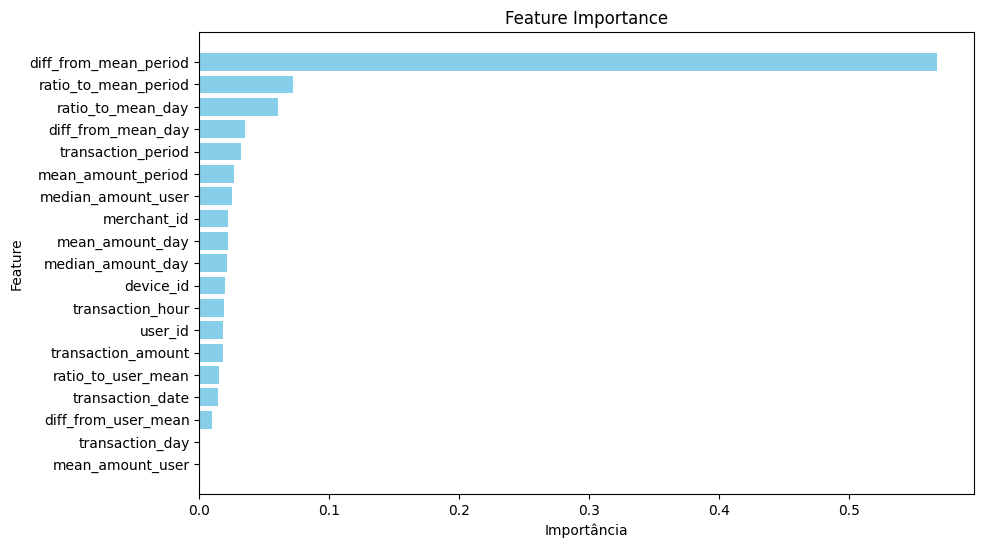

                  feature  importance
13  diff_from_mean_period    0.568279
14   ratio_to_mean_period    0.071859
11      ratio_to_mean_day    0.060242
10     diff_from_mean_day    0.035268
7      transaction_period    0.032188
12     mean_amount_period    0.026977
16     median_amount_user    0.025008
0             merchant_id    0.022460
8         mean_amount_day    0.022425
9       median_amount_day    0.021036


In [61]:
# Pegar importâncias
importances = model.feature_importances_
features = x_train.columns.to_list()  # se você usou pandas DataFrame, fica mais fácil

# Criar dataframe
feat_imp = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Plotar
plt.figure(figsize=(10, 6))
plt.barh(feat_imp['feature'], feat_imp['importance'], color="skyblue")
plt.gca().invert_yaxis()  # maior importância no topo
plt.title("Feature Importance")
plt.xlabel("Importância")
plt.ylabel("Feature")
plt.show()

# Mostrar top 10
print(feat_imp.head(10))

## Use Case